# Breast Cancer Classification Using Logistic Regression

A Python analysis of the Wisconsin Diagnostic Breast Cancer dataset. This notebook is for educational purposes and is not a clinical diagnostic tool.

In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_breast_cancer

In [15]:
cancer = load_breast_cancer()
type(cancer)

sklearn.utils._bunch.Bunch

In [16]:
cancer.keys()

dict_keys(['data', 'target', 'frame', 'target_names', 'DESCR', 'feature_names', 'filename', 'data_module'])

In [17]:
cancer.data.shape

(569, 30)

In [18]:
cancer.feature_names

array(['mean radius', 'mean texture', 'mean perimeter', 'mean area',
       'mean smoothness', 'mean compactness', 'mean concavity',
       'mean concave points', 'mean symmetry', 'mean fractal dimension',
       'radius error', 'texture error', 'perimeter error', 'area error',
       'smoothness error', 'compactness error', 'concavity error',
       'concave points error', 'symmetry error',
       'fractal dimension error', 'worst radius', 'worst texture',
       'worst perimeter', 'worst area', 'worst smoothness',
       'worst compactness', 'worst concavity', 'worst concave points',
       'worst symmetry', 'worst fractal dimension'], dtype='<U23')

In [19]:
cancer.target_names

array(['malignant', 'benign'], dtype='<U9')

In [20]:
np.unique(cancer.target, return_counts = True)

(array([0, 1]), array([212, 357]))

In [24]:
df = pd.DataFrame(
        cancer.data,
        columns = cancer.feature_names
)
df.head()

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


In [28]:
df["target"] = cancer.target
df.head()

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,0
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,0
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,0
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,0
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,0


In [45]:
df["diagnosis"] = df["target"].map({
    0: "malignant",
    1: "benign"
})

In [35]:
df[["target", "diagnosis"]].head(10)

,target,diagnosis
0,0,malignant
1,0,malignant
2,0,malignant
3,0,malignant
4,0,malignant
5,0,malignant
6,0,malignant
7,0,malignant
8,0,malignant
9,0,malignant


In [36]:
df.shape

(569, 32)

In [37]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 32 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   mean radius              569 non-null    float64
 1   mean texture             569 non-null    float64
 2   mean perimeter           569 non-null    float64
 3   mean area                569 non-null    float64
 4   mean smoothness          569 non-null    float64
 5   mean compactness         569 non-null    float64
 6   mean concavity           569 non-null    float64
 7   mean concave points      569 non-null    float64
 8   mean symmetry            569 non-null    float64
 9   mean fractal dimension   569 non-null    float64
 10  radius error             569 non-null    float64
 11  texture error            569 non-null    float64
 12  perimeter error          569 non-null    float64
 13  area error               569 non-null    float64
 14  smoothness error         569 non-null

In [38]:
df["diagnosis"].value_counts()

diagnosis
benign       357
malignant    212
Name: count, dtype: int64

In [39]:
df.isna().sum().sum()

np.int64(0)

In [40]:
df["diagnosis"].value_counts(True)

diagnosis
benign       0.627417
malignant    0.372583
Name: proportion, dtype: float64

In [41]:
df.describe()

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
count,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,...,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000
mean,14.127292,19.289649,91.969033,654.889104,0.096360,0.104341,0.088799,0.048919,0.181162,0.062798,...,25.677223,107.261213,880.583128,0.132369,0.254265,0.272188,0.114606,0.290076,0.083946,0.627417
std,3.524049,4.301036,24.298981,351.914129,0.014064,0.052813,0.079720,0.038803,0.027414,0.007060,...,6.146258,33.602542,569.356993,0.022832,0.157336,0.208624,0.065732,0.061867,0.018061,0.483918
min,6.981000,9.710000,43.790000,143.500000,0.052630,0.019380,0.000000,0.000000,0.106000,0.049960,...,12.020000,50.410000,185.200000,0.071170,0.027290,0.000000,0.000000,0.156500,0.055040,0.000000
25%,11.700000,16.170000,75.170000,420.300000,0.086370,0.064920,0.029560,0.020310,0.161900,0.057700,...,21.080000,84.110000,515.300000,0.116600,0.147200,0.114500,0.064930,0.250400,0.071460,0.000000
50%,13.370000,18.840000,86.240000,551.100000,0.095870,0.092630,0.061540,0.033500,0.179200,0.061540,...,25.410000,97.660000,686.500000,0.131300,0.211900,0.226700,0.099930,0.282200,0.080040,1.000000
75%,15.780000,21.800000,104.100000,782.700000,0.105300,0.130400,0.130700,0.074000,0.195700,0.066120,...,29.720000,125.400000,1084.000000,0.146000,0.339100,0.382900,0.161400,0.317900,0.092080,1.000000
max,28.110000,39.280000,188.500000,2501.000000,0.163400,0.345400,0.426800,0.201200,0.304000,0.097440,...,49.540000,251.200000,4254.000000,0.222600,1.058000,1.252000,0.291000,0.663800,0.207500,1.000000


In [42]:
df["mean radius"].describe()

count    569.000000
mean      14.127292
std        3.524049
min        6.981000
25%       11.700000
50%       13.370000
75%       15.780000
max       28.110000
Name: mean radius, dtype: float64

In [43]:
df.groupby("diagnosis")["mean radius"].describe()

,count,mean,std,min,25%,50%,75%,max
diagnosis,,,,,,,,
benign,357.0,12.146524,1.780512,6.981,11.080,12.200,13.37,17.85
malignant,212.0,17.462830,3.203971,10.950,15.075,17.325,19.59,28.11


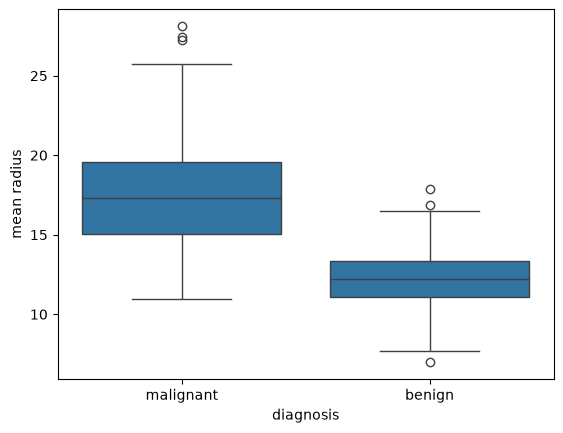

In [47]:
sns.boxplot(
    data = df,
    x = "diagnosis",
    y = "mean radius",
)
plt.show()

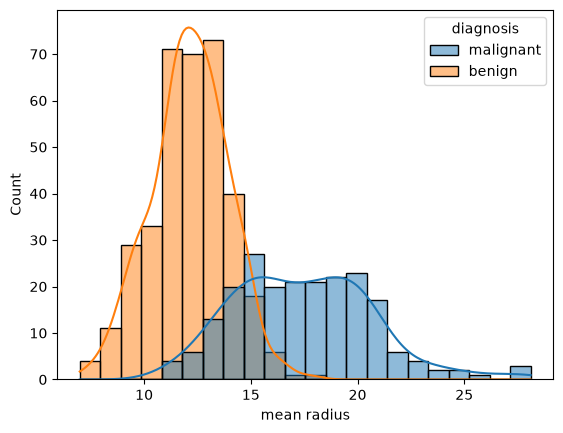

In [51]:
sns.histplot(
    data = df,
    x = "mean radius",
    hue = "diagnosis",
    kde = True
)
plt.show()

In [52]:
features = [
    "mean radius",
    "mean texture",
    "mean area",
    "mean concavity",
    "mean concave points"
]
df.groupby("diagnosis")[features].mean()

,mean radius,mean texture,mean area,mean concavity,mean concave points
diagnosis,,,,,
benign,12.146524,17.914762,462.790196,0.046058,0.025717
malignant,17.462830,21.604906,978.376415,0.160775,0.087990


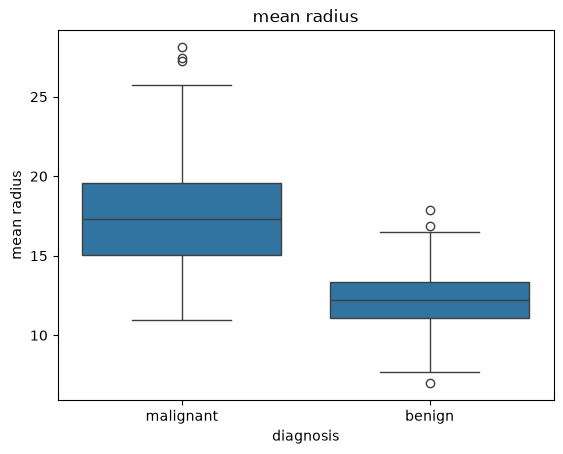

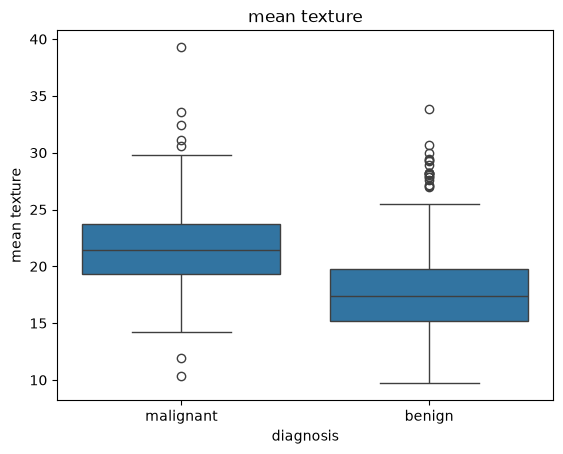

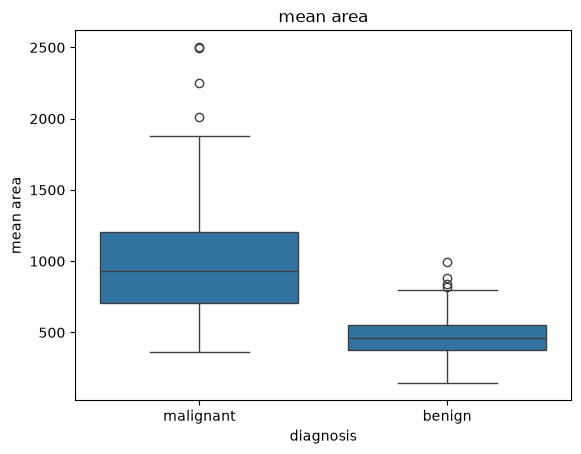

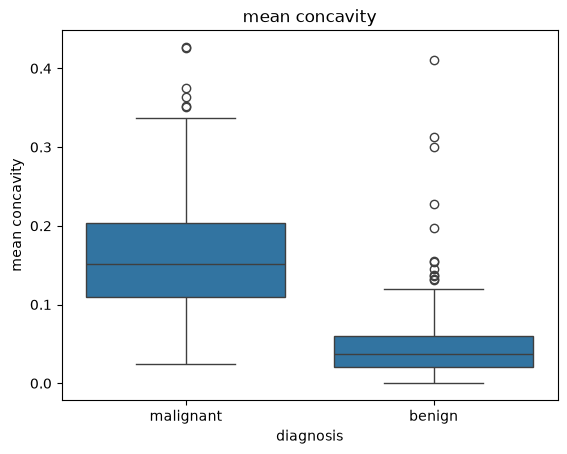

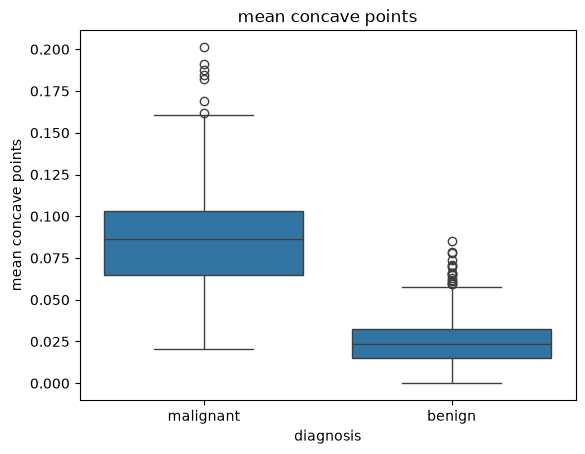

In [56]:
for feature in features:
    sns.boxplot(
        data = df,
        x = "diagnosis",
        y = feature,
    )
    plt.title(feature)
    plt.show()

In [58]:
df["mean radius"].corr(df["mean area"])

np.float64(0.9873571700566125)

In [59]:
df["mean radius"].corr(df["mean perimeter"])

np.float64(0.9978552814938104)

In [65]:
feature_df = df[cancer.feature_names]
correlation_matrix = feature_df.corr()
correlation_matrix.head()
correlation_matrix.shape

(30, 30)

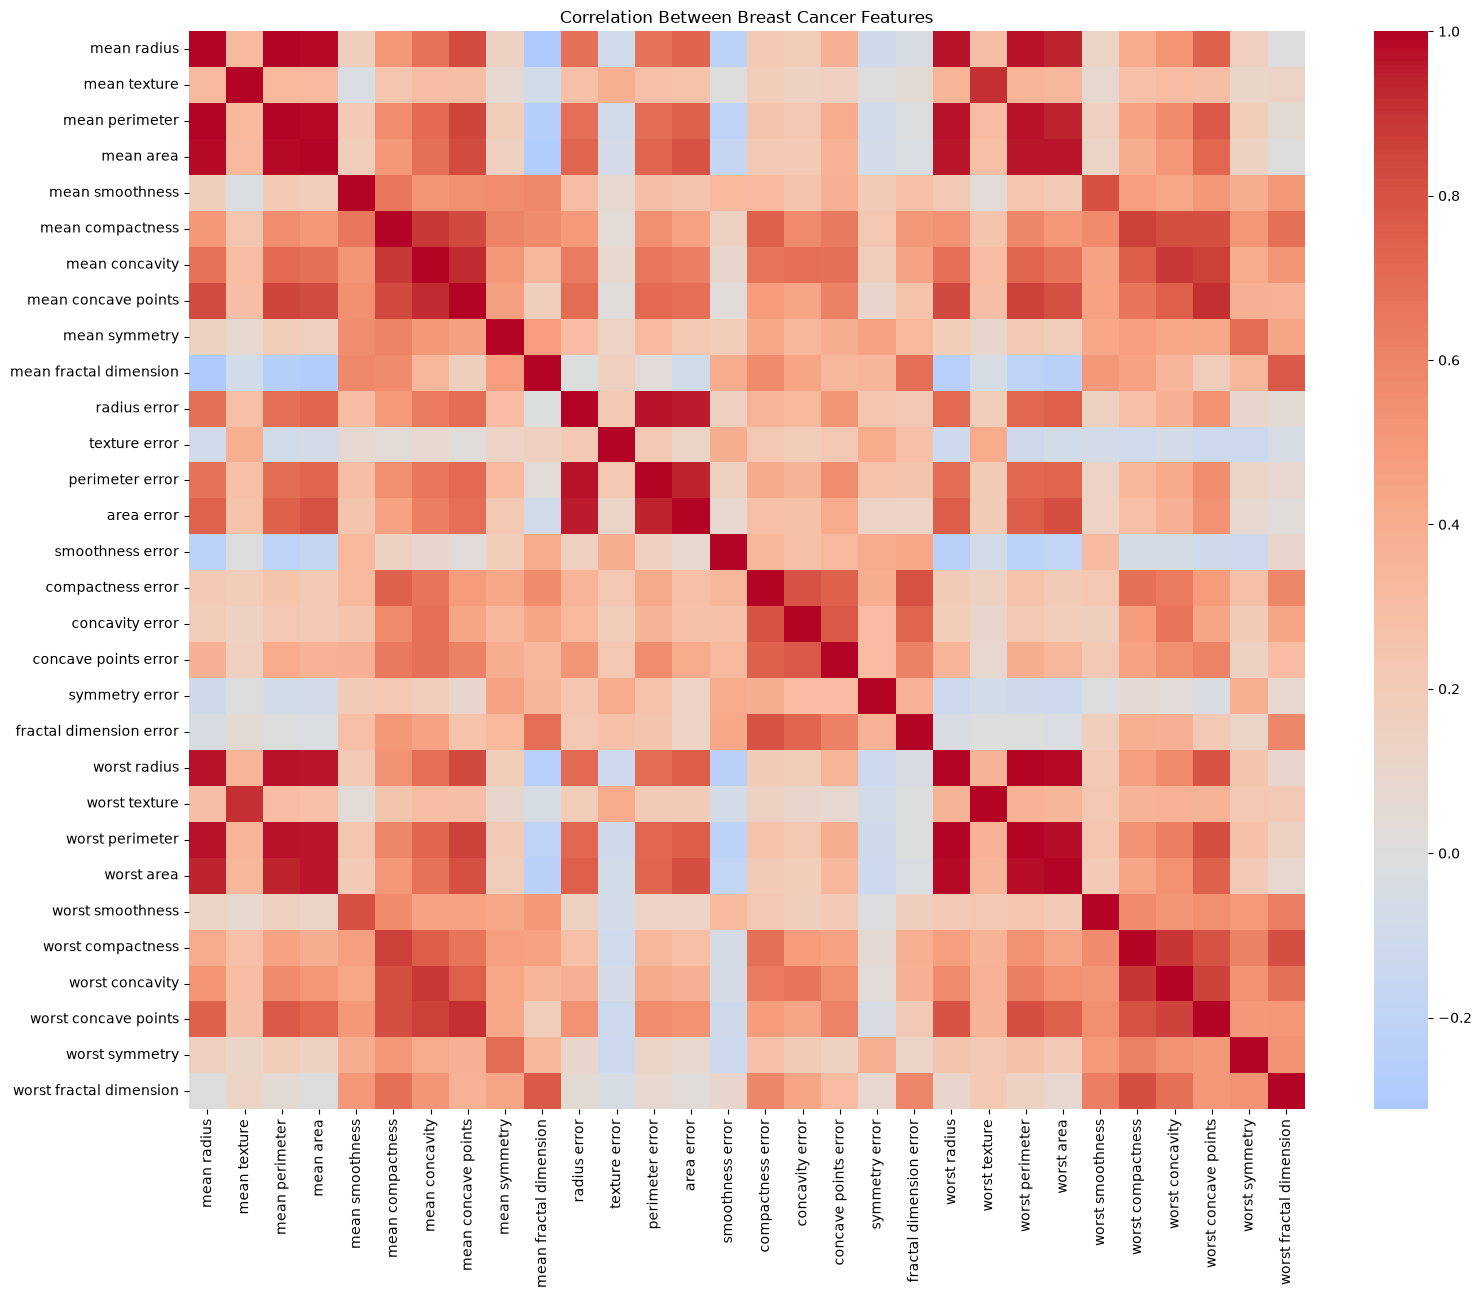

In [66]:
plt.figure(figsize = (18,14))

sns.heatmap(
    correlation_matrix,
    cmap = "coolwarm",
    center = 0
)

plt.title("Correlation Between Breast Cancer Features")
plt.show()


In [69]:
correlation_matrix.abs()

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
mean radius,1.000000,0.323782,0.997855,0.987357,0.170581,0.506124,0.676764,0.822529,0.147741,0.311631,...,0.969539,0.297008,0.965137,0.941082,0.119616,0.413463,0.526911,0.744214,0.163953,0.007066
mean texture,0.323782,1.000000,0.329533,0.321086,0.023389,0.236702,0.302418,0.293464,0.071401,0.076437,...,0.352573,0.912045,0.358040,0.343546,0.077503,0.277830,0.301025,0.295316,0.105008,0.119205
mean perimeter,0.997855,0.329533,1.000000,0.986507,0.207278,0.556936,0.716136,0.850977,0.183027,0.261477,...,0.969476,0.303038,0.970387,0.941550,0.150549,0.455774,0.563879,0.771241,0.189115,0.051019
mean area,0.987357,0.321086,0.986507,1.000000,0.177028,0.498502,0.685983,0.823269,0.151293,0.283110,...,0.962746,0.287489,0.959120,0.959213,0.123523,0.390410,0.512606,0.722017,0.143570,0.003738
mean smoothness,0.170581,0.023389,0.207278,0.177028,1.000000,0.659123,0.521984,0.553695,0.557775,0.584792,...,0.213120,0.036072,0.238853,0.206718,0.805324,0.472468,0.434926,0.503053,0.394309,0.499316
mean compactness,0.506124,0.236702,0.556936,0.498502,0.659123,1.000000,0.883121,0.831135,0.602641,0.565369,...,0.535315,0.248133,0.590210,0.509604,0.565541,0.865809,0.816275,0.815573,0.510223,0.687382
mean concavity,0.676764,0.302418,0.716136,0.685983,0.521984,0.883121,1.000000,0.921391,0.500667,0.336783,...,0.688236,0.299879,0.729565,0.675987,0.448822,0.754968,0.884103,0.861323,0.409464,0.514930
mean concave points,0.822529,0.293464,0.850977,0.823269,0.553695,0.831135,0.921391,1.000000,0.462497,0.166917,...,0.830318,0.292752,0.855923,0.809630,0.452753,0.667454,0.752399,0.910155,0.375744,0.368661
mean symmetry,0.147741,0.071401,0.183027,0.151293,0.557775,0.602641,0.500667,0.462497,1.000000,0.479921,...,0.185728,0.090651,0.219169,0.177193,0.426675,0.473200,0.433721,0.430297,0.699826,0.438413
mean fractal dimension,0.311631,0.076437,0.261477,0.283110,0.584792,0.565369,0.336783,0.166917,0.479921,1.000000,...,0.253691,0.051269,0.205151,0.231854,0.504942,0.458798,0.346234,0.175325,0.334019,0.767297


In [70]:
high_corr_pairs = []

for i in range(len(correlation_matrix.columns)):
    for j in range(i):
        correlation = correlation_matrix.iloc[i,j]

        if abs(correlation) > 0.90:
            high_corr_pairs.append(
                (
                    correlation_matrix.columns[i],
                    correlation_matrix.columns[j],
                    correlation
                )
            )
                
        

In [72]:
high_corr_pairs[:10]

[('mean perimeter', 'mean radius', np.float64(0.9978552814938106)),
 ('mean area', 'mean radius', np.float64(0.9873571700566129)),
 ('mean area', 'mean perimeter', np.float64(0.9865068039913908)),
 ('mean concave points', 'mean concavity', np.float64(0.921391026378859)),
 ('perimeter error', 'radius error', np.float64(0.9727936770160764)),
 ('area error', 'radius error', np.float64(0.951830112110991)),
 ('area error', 'perimeter error', np.float64(0.9376554069544158)),
 ('worst radius', 'mean radius', np.float64(0.9695389726112049)),
 ('worst radius', 'mean perimeter', np.float64(0.9694763634663146)),
 ('worst radius', 'mean area', np.float64(0.9627460860470841))]

In [80]:
high_corr_pairs_sorted = sorted(
    high_corr_pairs,
    key = lambda x: abs(x[2]),
    reverse = True
    )
high_corr_pairs_sorted[:15]

[('mean perimeter', 'mean radius', np.float64(0.9978552814938106)),
 ('worst perimeter', 'worst radius', np.float64(0.993707916102949)),
 ('mean area', 'mean radius', np.float64(0.9873571700566129)),
 ('mean area', 'mean perimeter', np.float64(0.9865068039913908)),
 ('worst area', 'worst radius', np.float64(0.9840145644590745)),
 ('worst area', 'worst perimeter', np.float64(0.9775780914063873)),
 ('perimeter error', 'radius error', np.float64(0.9727936770160764)),
 ('worst perimeter', 'mean perimeter', np.float64(0.9703868870426395)),
 ('worst radius', 'mean radius', np.float64(0.9695389726112049)),
 ('worst radius', 'mean perimeter', np.float64(0.9694763634663146)),
 ('worst perimeter', 'mean radius', np.float64(0.9651365139559871)),
 ('worst radius', 'mean area', np.float64(0.9627460860470841)),
 ('worst area', 'mean area', np.float64(0.9592133256498999)),
 ('worst perimeter', 'mean area', np.float64(0.9591195743552647)),
 ('area error', 'radius error', np.float64(0.951830112110991))

In [85]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline

X = df[cancer.feature_names]
y = df["target"]

In [88]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size = 0.20,
    random_state = 42,
    stratify = y
)

X_train.shape

(114, 30)

In [89]:
X_test.shape

(114, 30)

In [90]:
y_train.value_counts(normalize = True)
y_test.value_counts(normalize = True)


target
1    0.631579
0    0.368421
Name: proportion, dtype: float64

In [91]:
model = Pipeline([
    ("scaler", StandardScaler()),
    ("classifier", LogisticRegression(max_iter = 1000))
])

model.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('scaler', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](30,)","['mean radius','mean texture','mean perimeter',...,'worst concave points', 'worst symmetry','worst fractal dimension']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,30
,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True


In [92]:
y_pred = model.predict(X_test)

In [93]:
y_pred[:20]

array([0, 1, 0, 1, 0, 1, 1, 0, 0, 0, 1, 0, 1, 0, 0, 1, 0, 1, 1, 1])

In [100]:
comparison = pd.DataFrame({
    "actual": y_test.values,
    "predicted": y_pred
})

comparison.head(20)

,actual,predicted
0,0,0
1,1,1
2,0,0
3,1,1
4,0,0
5,1,1
6,1,1
7,0,0
8,0,0
9,0,0


In [102]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred)

accuracy


0.9824561403508771

In [103]:
from sklearn.metrics import (
    confusion_matrix,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report
)

In [104]:
cm = confusion_matrix(y_test, y_pred)

cm

array([[41,  1],
       [ 1, 71]])

In [111]:
cm_df = pd.DataFrame(
    cm,
    index=["Actual Malignant", "Actual Benign"],
    columns=["Predicted Malignant", "Predicted Benign"]
)

cm_df

,Predicted Malignant,Predicted Benign
Actual Malignant,41,1
Actual Benign,1,71


In [110]:
accuracy = accuracy_score(y_test, y_pred)
accuracy

0.9824561403508771

In [112]:
TP = cm[0, 0]
FN = cm[0, 1]
FP = cm[1, 0]
TN = cm[1, 1]

In [113]:
specificity = TN/(TN+FP)
specificity

np.float64(0.9861111111111112)

In [115]:
precision_malignant = TP/(TP+FP)
precision_malignant

np.float64(0.9761904761904762)

In [117]:
sensitivity = TP / (TP + FN)

sensitivity


f1_malignant = 2 * (
    precision_malignant * sensitivity
) / (
    precision_malignant + sensitivity
)

f1_malignant

np.float64(0.9761904761904762)

In [118]:
metrics = pd.DataFrame({
    "Metric": [
        "Accuracy",
        "Sensitivity",
        "Specificity",
        "Precision (Malignant)",
        "F1 (Malignant)"
    ],
    "Score": [
        accuracy,
        sensitivity,
        specificity,
        precision_malignant,
        f1_malignant
    ]
})

metrics

,Metric,Score
0,Accuracy,0.982456
1,Sensitivity,0.976190
2,Specificity,0.986111
3,Precision (Malignant),0.976190
4,F1 (Malignant),0.976190


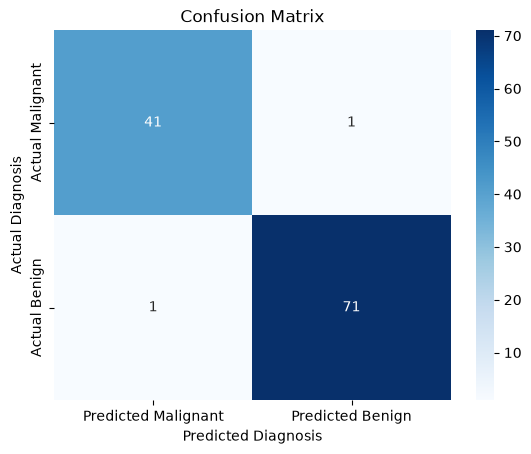

In [121]:
sns.heatmap(
    cm_df,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.title("Confusion Matrix")
plt.ylabel("Actual Diagnosis")
plt.xlabel("Predicted Diagnosis")
plt.show()

In [122]:
print(
    classification_report(
        y_test,
        y_pred,
        target_names=["malignant", "benign"]
    )
)

              precision    recall  f1-score   support

   malignant       0.98      0.98      0.98        42
      benign       0.99      0.99      0.99        72

    accuracy                           0.98       114
   macro avg       0.98      0.98      0.98       114
weighted avg       0.98      0.98      0.98       114



In [123]:
model.predict(X_test)

array([0, 1, 0, 1, 0, 1, 1, 0, 0, 0, 1, 0, 1, 0, 0, 1, 0, 1, 1, 1, 0, 0,
       1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 0, 0, 1, 1, 1, 0, 1, 1, 1, 0,
       0, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 0, 0, 1, 1, 1, 1, 1, 0, 0,
       1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 1, 1, 1, 1, 1, 0, 1, 0, 1, 1, 1,
       1, 1, 1, 1, 0, 0, 0, 1, 0, 1, 0, 1, 0, 0, 0, 1, 0, 0, 1, 0, 1, 0,
       1, 0, 1, 1])

In [124]:
y_prob = model.predict_proba(X_test)

In [127]:
y_prob[:5]

array([[9.99999941e-01, 5.88824186e-08],
       [1.13351672e-05, 9.99988665e-01],
       [9.93589175e-01, 6.41082462e-03],
       [4.66491463e-01, 5.33508537e-01],
       [9.99999999e-01, 6.52500097e-10]])

In [131]:

malignant_prob = y_prob[:, 0]

y_test_malignant = (y_test == 0).astype(int)

roc_auc = roc_auc_score(
    y_test_malignant,
    malignant_prob
)

roc_auc

0.9953703703703705

In [132]:
from sklearn.model_selection import StratifiedKFold, cross_val_score

In [133]:
cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

In [134]:
cv_scores = cross_val_score(
    model,
    X,
    y,
    cv=cv,
    scoring="accuracy"
)

In [135]:
cv_scoresy

array([0.97368421, 0.94736842, 0.96491228, 0.99122807, 0.99115044])

In [137]:
cv_scores.mean()

np.float64(0.9736686849868033)

In [138]:
cv_scores.std()

np.float64(0.016627222216787987)

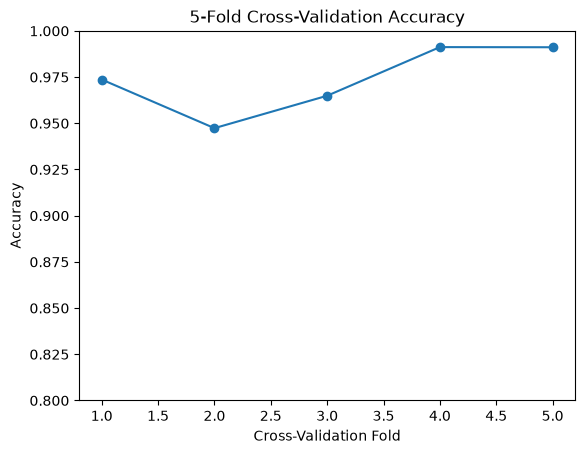

In [140]:
plt.plot(
    range(1,6),
    cv_scores,
    marker = "o"
)

plt.xlabel("Cross-Validation Fold")
plt.ylabel("Accuracy")
plt.title("5-Fold Cross-Validation Accuracy")
plt.ylim(0.8,1.0)
plt.show()

In [144]:
from sklearn.metrics import make_scorer, recall_score

malignant_recall = make_scorer(
    recall_score,
    pos_label = 0
)

In [146]:
recall_scores = cross_val_score(
    model,
    X,
    y,
    cv=cv,
    scoring=malignant_recall
    )
recall_scores

array([0.97674419, 0.86046512, 0.9047619 , 1.        , 0.97619048])

In [147]:
print("Mean Malignant Sensitivity", recall_scores.mean())
print("Sensitivity SD", recall_scores.std())

Mean Malignant Sensitivity 0.9436323366555925
Sensitivity SD 0.052462248353892044


In [148]:
classifier = model.named_steps["classifier"]

In [149]:
classifier.coef_.shape

(1, 30)

In [150]:
classifier.coef_[0]

array([-0.51147901, -0.55269775, -0.47629789, -0.54105924, -0.21247927,
        0.64834159, -0.60210291, -0.70415649, -0.16723273,  0.19973173,
       -1.08296534,  0.24882301, -0.54433323, -0.92910402, -0.16027571,
        0.64722656,  0.16056252, -0.44378424,  0.36049156,  0.43789426,
       -0.94761615, -1.25508804, -0.76322007, -0.9477559 , -0.74662481,
        0.05551412, -0.82315065, -0.95368636, -0.93918141, -0.1872508 ])

In [154]:
coef_df = pd.DataFrame({
    "feature": cancer.feature_names,
    "coefficient": classifier.coef_[0]
})

coef_df.head()

,feature,coefficient
0,mean radius,-0.511479
1,mean texture,-0.552698
2,mean perimeter,-0.476298
3,mean area,-0.541059
4,mean smoothness,-0.212479


In [155]:
coef_df_sorted = coef_df.sort_values(
    by = "coefficient"
)
coef_df_sorted

,feature,coefficient
21,worst texture,-1.255088
10,radius error,-1.082965
27,worst concave points,-0.953686
23,worst area,-0.947756
20,worst radius,-0.947616
28,worst symmetry,-0.939181
13,area error,-0.929104
26,worst concavity,-0.823151
22,worst perimeter,-0.763220
24,worst smoothness,-0.746625


In [157]:
coef_df["abs_coefficient"] = coef_df["coefficient"].abs()

In [158]:
coef_df.sort_values(
    "abs_coefficient",
    ascending = False
).head(10)

,feature,coefficient,abs_coefficient
21,worst texture,-1.255088,1.255088
10,radius error,-1.082965,1.082965
27,worst concave points,-0.953686,0.953686
23,worst area,-0.947756,0.947756
20,worst radius,-0.947616,0.947616
28,worst symmetry,-0.939181,0.939181
13,area error,-0.929104,0.929104
26,worst concavity,-0.823151,0.823151
22,worst perimeter,-0.763220,0.763220
24,worst smoothness,-0.746625,0.746625


In [1]:
%pwd

'/Users/aarusharora/anaconda_projects'